# Klassifikation emotionaler Intensität in Filmrezensionen

## Ziel

Dieses Notebook dokumentiert die Entwicklung einer Klassifikation emotionaler Intensität in Filmrezensionen.

Die Experimente zeigen die Entwicklung der Forschungslogik:

1. Baseline
2. 100k-Stichprobe
3. 500k-Stichprobe
4. vollständiger Datensatz
5. Binary Classification: Low vs. High
6. Cleaner TF-IDF Features
7. TF-IDF with Bigrams
8. Rule-Based Target mit dominanter Emotion
9. finales Rule-Based Target mit dem besten Ergebnis

Wichtig ist außerdem die methodische Erkenntnis, dass das Hugging-Face-Emotion-Modell Softmax-normalisierte Scores ausgibt. Dadurch ist `non_neutral_sum` mathematisch äquivalent zu `1 - neutral`.
Da die Emotionsscores durch eine Softmax-Funktion normiert sind, führt ein hoher Neutral-Score automatisch zu niedrigeren Werten der übrigen Emotionen. Die Definition `emotional_intensity = 1 - neutral` misst daher primär den Grad der Nicht-Neutralität eines Textes und nicht notwendigerweise die tatsächliche Stärke einer einzelnen Emotion.

# Daten

## Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.dummy import DummyClassifier


RANDOM_STATE = 42

## Stop Words

In [72]:
len(ENGLISH_STOP_WORDS)

318

In [73]:
list(ENGLISH_STOP_WORDS)[:318]

['few',
 'behind',
 'had',
 'part',
 'show',
 'becomes',
 'beside',
 'was',
 'already',
 'give',
 'hers',
 'although',
 'what',
 'take',
 'out',
 'been',
 'now',
 'yourself',
 'seem',
 'otherwise',
 'third',
 'besides',
 'itself',
 'next',
 'own',
 'interest',
 'never',
 'go',
 'your',
 'whither',
 'whereas',
 'hundred',
 'whom',
 'twelve',
 'latter',
 'they',
 'etc',
 'fill',
 'who',
 'down',
 'cry',
 'indeed',
 'done',
 'around',
 'sixty',
 'such',
 'though',
 'whereby',
 'ie',
 'me',
 'seeming',
 'thin',
 'between',
 'have',
 'as',
 'get',
 'her',
 'find',
 'us',
 'together',
 'on',
 'because',
 'from',
 'myself',
 'un',
 'someone',
 'often',
 'our',
 'for',
 'please',
 'how',
 'many',
 'perhaps',
 'before',
 'too',
 'not',
 'when',
 'back',
 'meanwhile',
 'while',
 'cannot',
 'almost',
 'may',
 'side',
 'latterly',
 'could',
 'more',
 'an',
 'however',
 'do',
 'eg',
 'cant',
 'top',
 'thru',
 'he',
 'again',
 'hasnt',
 'everything',
 'without',
 'am',
 'which',
 'still',
 'less',
 

In [5]:
custom_stop_words = set(ENGLISH_STOP_WORDS) - {
    "not",
    "no",
    "never",
    "very",
    "interest",
    "serious",
    "already",
    "sincere",
    "enough",
    "none",
    "however",
    "more",
    "alone",
    "over",
    "again",
    "mostly",
    "off",
    "neither",
    "nothing",
    "down"
}

len(custom_stop_words)

298

## Daten laden

In [6]:
reviews_clean = pd.read_csv(
    "../Dataset/reviews_clean.csv"
)

## Samples

In [25]:
classification_sample_50k = reviews_clean.sample(
    n=50000,
    random_state=RANDOM_STATE
)
classification_sample_50k.shape
# runtime für 1000 = 15.05 sec
# runtime für 10 000 = 2.5 min
# runtime für 50 000 = 11 min

(50000, 14)

In [7]:
classification_sample_100k = reviews_clean.sample(
    n=100000,
    random_state=RANDOM_STATE
)
classification_sample_100k.shape
# runtime für 100 000 = 18.13 min

(100000, 14)

In [77]:
classification_sample_500k = reviews_clean.sample(
    n=500000,
    random_state=RANDOM_STATE
)
classification_sample_500k.shape
# runtime für 500 000 = 3 St.27 min

(500000, 14)

In [7]:
classification_full = reviews_clean.copy()

classification_full.shape

(1323533, 14)

# Emotion Model

In [ ]:
# Vortrainiertes Emotionsmodell aus HuggingFace

classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

#### Measure Emotion Model Runtime

In [11]:
sample_texts = classification_sample_50k["reviewText"]

In [12]:
import time

start = time.time()
results = sample_texts.apply(classifier)
end = time.time()

print(f"Total time: {end-start:.2f} seconds")
print(f"Time per review: {(end-start)/len(sample_texts):.4f} seconds")

Total time: 677.28 seconds
Time per review: 0.0135 seconds


#### Model Control

In [13]:
#Struktur des Modellergebnisses anzeigen

# iloc = integer location
# Zugriff auf Zeilen über ihre Position im DataFrame
# iloc[0] liefert die erste Zeile bzw. den ersten Eintrag

example = classification_sample_50k["reviewText"].iloc[0]
result = classifier(example)
result

[[{'label': 'neutral', 'score': 0.6299400329589844},
  {'label': 'joy', 'score': 0.2578708529472351},
  {'label': 'disgust', 'score': 0.06635477393865585},
  {'label': 'sadness', 'score': 0.021305464208126068},
  {'label': 'fear', 'score': 0.010636403225362301},
  {'label': 'surprise', 'score': 0.007409465499222279},
  {'label': 'anger', 'score': 0.006482984405010939}]]

In [12]:
#emotion_labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

def get_emotion_scores(text):
    result = classifier(str(text))[0]
    return {item["label"]: item["score"] for item in result}

In [13]:
get_emotion_scores(
    "This movie was absolutely fantastic. I loved every minute of it."
)

{'joy': 0.9731166362762451,
 'neutral': 0.010996730998158455,
 'surprise': 0.007519790902733803,
 'disgust': 0.0038554880302399397,
 'anger': 0.0016190174501389265,
 'fear': 0.0015236452454701066,
 'sadness': 0.0013686285819858313}

In [16]:
get_emotion_scores(
    "This was the worst movie I have ever seen."
)

{'disgust': 0.9814790487289429,
 'anger': 0.010307026095688343,
 'sadness': 0.0030735123436897993,
 'neutral': 0.0023971593473106623,
 'fear': 0.001570962369441986,
 'surprise': 0.0008430869784206152,
 'joy': 0.0003292049514129758}

In [17]:
get_emotion_scores(
    "The movie was released in 2020 and has a runtime of two hours."
)

{'neutral': 0.7709848880767822,
 'joy': 0.14732182025909424,
 'surprise': 0.0421702042222023,
 'sadness': 0.02783505618572235,
 'anger': 0.005260132253170013,
 'disgust': 0.005187879782170057,
 'fear': 0.0012399714905768633}

In [18]:
get_emotion_scores(
    "The ending made me cry and left me feeling empty."
)

{'sadness': 0.9819384813308716,
 'neutral': 0.008232833817601204,
 'disgust': 0.0048576039262115955,
 'surprise': 0.0014785736566409469,
 'anger': 0.001356800552457571,
 'joy': 0.0010907987598329782,
 'fear': 0.00104496197309345}

In [19]:
test_texts = [
    "The movie was released in 2020 and runs for two hours.",
    "This movie was absolutely fantastic. I loved it.",
    "This was the worst movie I have ever seen.",
    "The ending made me cry.",
    "This movie was absolutely nothing special.",
    "The film tells the story of a family living in New York."
]

for text in test_texts:
    result = get_emotion_scores(text)

    print("\nTEXT:")
    print(text)

    print("\nNEUTRAL:")
    print(round(result["neutral"], 3))

    print("\nTOP EMOTION:")
    print(max(result, key=result.get))

    print("-" * 50)


TEXT:
The movie was released in 2020 and runs for two hours.

NEUTRAL:
0.543

TOP EMOTION:
neutral
--------------------------------------------------

TEXT:
This movie was absolutely fantastic. I loved it.

NEUTRAL:
0.007

TOP EMOTION:
joy
--------------------------------------------------

TEXT:
This was the worst movie I have ever seen.

NEUTRAL:
0.002

TOP EMOTION:
disgust
--------------------------------------------------

TEXT:
The ending made me cry.

NEUTRAL:
0.059

TOP EMOTION:
sadness
--------------------------------------------------

TEXT:
This movie was absolutely nothing special.

NEUTRAL:
0.462

TOP EMOTION:
neutral
--------------------------------------------------

TEXT:
The film tells the story of a family living in New York.

NEUTRAL:
0.177

TOP EMOTION:
joy
--------------------------------------------------


In [26]:
# real phrases control
sample_20 = classification_sample_50k["reviewText"].sample(
    20,
    random_state=RANDOM_STATE
)

In [27]:
for text in sample_20:
    scores = get_emotion_scores(text)

    print(f"neutral = {scores['neutral']:.3f}")
    print(text[:200])
    print("-" * 80)

neutral = 0.005
It's said that the most of the 'horror' in classic horror films is derived from the sound effects and background score. Director John Krasinski has turned that dictum upon its head.
--------------------------------------------------------------------------------
neutral = 0.017
Nick Kozakis&#8217; tragedy of faith subjects a mentally ill heroine to her community&#8217;s blind belief
--------------------------------------------------------------------------------
neutral = 0.046
The plot is a shambles, designed not so much to tell a story as to link together a variety of scenes in which someone mutters a few choice words after being riddled with bullets and before expiring.
--------------------------------------------------------------------------------
neutral = 0.015
A gripping movie about a time when America still worked.
--------------------------------------------------------------------------------
neutral = 0.883
The story of Donald Rugoff is not just the story of

#### Preliminary Evaluation of the Emotion Model
Zur ersten Überprüfung des Modells wurden mehrere Beispieltexte und zufällig ausgewählte Reviews analysiert.

Die Ergebnisse zeigen, dass das Modell emotionale Formulierungen grundsätzlich erkennt. Gleichzeitig wurden einige Einschränkungen festgestellt. Kritische Filmbewertungen, die in einem sachlichen und analytischen Stil geschrieben sind, werden häufig als „neutral“ eingestuft, obwohl sie eine negative Bewertung des Films enthalten.

Daraus schließen wir, dass das Modell eher die emotionale Ausdrucksstärke eines Textes misst als die positive oder negative Bewertung des Films.

Insgesamt erscheint das Modell für unser Projekt geeignet, da wir die emotionale Intensität von Reviews untersuchen möchten.

# Feature Engineering
Emotion Intensity Prediction

## Generate Emotion Scores

In [28]:
#die Emotionen für die gesamte Stichprobe.
emotion_scores = classification_sample_50k["reviewText"].apply(get_emotion_scores)

#Frame
emotion_scores_df = pd.DataFrame(emotion_scores.tolist())

In [29]:
emotion_scores_df.columns

Index(['neutral', 'joy', 'disgust', 'sadness', 'fear', 'surprise', 'anger'], dtype='str')

In [30]:
#Concatination classification_sample_50k mit emotions
classification_sample_50k = pd.concat(
    [
        classification_sample_50k.reset_index(drop=True),
        emotion_scores_df.reset_index(drop=True)
    ],
    axis=1
)
classification_sample_50k.shape

(50000, 21)

In [31]:
classification_sample_50k.columns.tolist()

['id',
 'reviewId',
 'creationDate',
 'criticName',
 'isTopCritic',
 'originalScore',
 'reviewState',
 'publicatioName',
 'reviewText',
 'scoreSentiment',
 'reviewUrl',
 'word_count',
 'language',
 'letter_ratio',
 'neutral',
 'joy',
 'disgust',
 'sadness',
 'fear',
 'surprise',
 'anger']

In [32]:
emotion_scores_df.columns.tolist()

['neutral', 'joy', 'disgust', 'sadness', 'fear', 'surprise', 'anger']

In [33]:
classification_sample_50k[
    [
        "reviewText",
        "anger",
        "disgust",
        "fear",
        "joy",
        "neutral",
        "sadness",
        "surprise"
    ]
].head()

,reviewText,anger,disgust,fear,joy,neutral,sadness,surprise
0,"Worth seeing and often very droll, as well as ...",0.006483,0.066355,0.010636,0.257871,0.629940,0.021305,0.007409
1,"It's a sweet, well-intentioned film.",0.002483,0.007371,0.000440,0.917970,0.063990,0.003375,0.004370
2,"The result is a spellbinding, and breathtaking...",0.001578,0.004631,0.034202,0.905096,0.023963,0.003120,0.027411
3,Dick Johnson is Dead is both a poetic act of d...,0.283273,0.212361,0.016296,0.015207,0.441720,0.026638,0.004505
4,"A profile of the Satanic Temple, the movie fol...",0.068652,0.788241,0.052556,0.005155,0.068657,0.015125,0.001613


## Softmax-Kontrolle des Emotion-Modells

Das Modell gibt Scores für sieben Klassen aus:

- `neutral`
- `surprise`
- `joy`
- `sadness`
- `anger`
- `disgust`
- `fear`

Da diese Scores Softmax-normalisiert sind, sollte ihre Summe pro Review ungefähr 1 ergeben.

In [34]:
emotion_cols_all = [
    "neutral",
    "surprise",
    "joy",
    "sadness",
    "anger",
    "disgust",
    "fear"
]

classification_sample_50k[emotion_cols_all].sum(axis=1).describe()

count    5.000000e+04
mean     1.000000e+00
std      5.572077e-08
min      9.999997e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

## Create Emotion Intensity Classes

Da die Emotionsscores durch eine Softmax-Funktion normiert sind, führt ein hoher Neutral-Score automatisch zu niedrigeren Werten der übrigen Emotionen. Die Definition emotional_intensity = 1 - neutral misst daher primär den Grad der Nicht-Neutralität eines Textes und nicht notwendigerweise die tatsächliche Stärke einer einzelnen Emotion.


Wir definieren emotionale Intensität als `1 - neutral`, da ein niedriger Neutralitätswert darauf hinweist, dass das Modell einen größeren Anteil der Wahrscheinlichkeit auf nicht-neutrale Emotionsklassen verteilt.

Diese Definition misst somit den Grad der Nicht-Neutralität eines Reviews.

Gleichzeitig hat diese Operationalisierung Grenzen. Da das Emotionsmodell Softmax-normalisierte Wahrscheinlichkeiten ausgibt, summieren sich alle Emotionswerte zu 1. Daher entspricht `1 - neutral` der Summe aller nicht-neutralen Emotionen.

Die Variable unterscheidet jedoch nicht zwischen Reviews mit einer klar dominierenden Emotion und Reviews mit mehreren gemischten Emotionen. Deshalb interpretieren wir `emotional_intensity` nicht als Stärke einer einzelnen Emotion, sondern als Maß für die allgemeine nicht-neutrale emotionale Aktivierung.

### Emotional Intensity Score

In [35]:
# Emotional Intensity = 1 - Neutral Emotion Score
classification_sample_50k ["emotional_intensity"] = (
    1 - classification_sample_50k ["neutral"]
)

In [36]:
classification_sample_50k ["emotional_intensity"].describe()

count    50000.000000
mean         0.629009
std          0.325486
min          0.021026
25%          0.320902
50%          0.730224
75%          0.935988
max          0.999639
Name: emotional_intensity, dtype: float64

### Variant 1. Emotion Intensity Classification (Fixed Thresholds)
Low:    0.00 – 0.33
Medium: 0.34 – 0.67
High:   0.68 – 1.00

In [37]:
def classify_intensity(x):
    if x <= 0.33:
        return "low"
    elif x <= 0.67:
        return "medium"
    else:
        return "high"

classification_sample_50k ["emotion_intensity_class"] = (
    classification_sample_50k ["emotional_intensity"]
    .apply(classify_intensity)
)


### Variant 2. Balanced Emotion Intensity Classes Using Quantiles

In [38]:
classification_sample_50k ["emotion_intensity_class_q"] = pd.qcut(
    classification_sample_50k ["emotional_intensity"],
    q=3,
    labels=["low", "medium", "high"]
)

### Comparison of Both Approaches

Two approaches were used to create emotion intensity classes.

The fixed-threshold approach uses predefined intensity intervals:
- low: 0.00–0.33
- medium: 0.34–0.67
- high: 0.68–1.00

The quantile-based approach divides the dataset into three equally sized groups. This produces balanced target classes and is therefore particularly suitable for machine learning experiments.

Both target variables are retained for further analysis and model comparison.

In [39]:
classification_sample_50k ["emotion_intensity_class"].value_counts()

emotion_intensity_class
high      27142
low       12778
medium    10080
Name: count, dtype: int64

In [40]:
classification_sample_50k ["emotion_intensity_class_q"].value_counts()

emotion_intensity_class_q
low       16667
high      16667
medium    16666
Name: count, dtype: int64

### Save Processed Classification Dataset

In [41]:
classification_sample_50k.to_csv(
    "../Dataset/classification_sample_50k_with_emotions.csv",
    index=False
)
print("Classification dataset saved.")

Classification dataset saved.


# Baseline

## Classification Approach

Goal:

Predict the emotional intensity class of a review
(low / medium / high)
based on the review text.

Input:
reviewText

Target:
emotion_intensity_class

Method:
TF-IDF Vectorization +
Logistic Regression Classifier

reviewText
↓
TF-IDF
↓
Logistic Regression
↓
emotion_intensity_class

## Dataset

In [108]:
classification_sample_50k = pd.read_csv(
    "../Dataset/classification_sample_50k_with_emotions.csv"
)

# Datensatz für dieses Experiment
data = classification_sample_50k
# experiment_name = "50k Sample"

## Train-Test Split

### Alter Ansatz. Explorative Definition von Quantilklassen
Zunächst wurden quantilbasierte Klassen auf dem gesamten Datensatz generiert, um die Klassenverteilung zu untersuchen. Für die Machine-Learning-Experimente werden die Quantilschwellenwerte jedoch nur anhand der Trainingsdaten bestimmt.

In [ ]:
'''
# target
y = classification_sample_50k["emotion_intensity_class_q"]
# die Klasse anhand des Textes vorhersagen
X = classification_sample_50k["reviewText"]
"""
Train/Test Split
stratify=y ist wichtig: Dadurch bleibt die Verteilung der Klassen low / medium / high in Trainings- und Testdaten gleich.
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())
'''

### Train-Test Split. Ohne Data Leakage

Die Quantilgrenzen werden ausschließlich auf dem Trainingsdatensatz bestimmt und anschließend auf den Testdatensatz angewendet.

Dadurch wird verhindert, dass Informationen aus dem Testdatensatz indirekt in die Definition der Zielvariablen einfließen (Data Leakage).

Dieses Vorgehen entspricht den üblichen Standards des maschinellen Lernens.

In [110]:
# Zielvariable (Emotionale Intensität (1 − Neutral-Score))

y_intensity = 1 - data["neutral"]

# Texte

X = data["reviewText"]

# Train-Test-Split

X_train, X_test, y_intensity_train, y_intensity_test = train_test_split(
    X,
    y_intensity,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [111]:
# Quantilgrenzen bestimmen

# Die Quantilgrenzen werden ausschließlich
# auf dem Trainingsdatensatz berechnet.

q1 = y_intensity_train.quantile(1/3)
q2 = y_intensity_train.quantile(2/3)

print("Untere Grenze:", q1)
print("Obere Grenze:", q2)

Untere Grenze: 0.463509738445282
Obere Grenze: 0.890152782201767


In [112]:
# Zielklassen erzeugen

# Einteilung der emotionalen Intensität
# in drei Klassen anhand der Trainingsquantile.

def assign_intensity_class(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"

In [113]:
# Klassen für Train und Test erstellen

# Die gleichen Schwellenwerte werden sowohl
# auf den Trainings- als auch auf den Testdatensatz angewendet.

y_train = y_intensity_train.apply(assign_intensity_class)
y_test = y_intensity_test.apply(assign_intensity_class)

In [114]:
# Klassenverteilung kontrollieren

# Kontrolle der Klassenverteilung
# im Trainings- und Testdatensatz.

print("Trainingsdaten:")
print(y_train.value_counts())

print()

print("Testdaten:")
print(y_test.value_counts())

Trainingsdaten:
neutral
low       13334
high      13333
medium    13333
Name: count, dtype: int64

Testdaten:
neutral
high      3395
low       3317
medium    3288
Name: count, dtype: int64


## TF-IDF Vectorization

The review texts are converted into numerical feature vectors using TF-IDF (Term Frequency–Inverse Document Frequency).

To reduce dimensionality and computational costs, only the 10,000 most informative terms are retained. Common English stop words (e.g. "the", "of", "and") are removed because they carry little information for predicting emotional intensity.
We use a custom English stop word list. Some words such as "not", "very", "never" and "interest" were removed from the default stop word list because they can be relevant for emotional intensity.

In [115]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

"""
fit_transform() nur auf den Trainingsdaten:
Der Vektorizer lernt hier das Vokabular und erstellt die TF-IDF-Merkmale.
transform() auf den Testdaten:
Es wird dasselbe Vokabular verwendet, ohne Informationen aus den Testdaten zu lernen.
Dadurch vermeiden wir Data Leakage.
"""

# train
X_train_tfidf = vectorizer.fit_transform(X_train)

# test
X_test_tfidf = vectorizer.transform(X_test)

## Logistic Regression Classifier

Für die erste Klassifikationsaufgabe wurde Logistic Regression als Baseline-Modell gewählt.

Gründe für diese Wahl:
- gut geeignet für Textklassifikation in Kombination mit TF-IDF-Merkmalen,
- schnell zu trainieren und zu interpretieren,
- liefert eine solide Baseline für den Vergleich mit komplexeren Modellen,
- funktioniert auch bei einer großen Anzahl von Merkmalen zuverlässig.

Der Parameter `max_iter=1000` wurde verwendet, da die TF-IDF-Vektorisierung bis zu 10.000 Merkmale erzeugt. Eine höhere Anzahl von Iterationen hilft dem Optimierungsverfahren, zuverlässig zu konvergieren und Convergence Warnings zu vermeiden.

In [116]:
# Logistic Regression als Baseline-Modell für die Textklassifikation
# max_iter=1000 erhöht die Anzahl der Optimierungsschritte und verhindert Convergence Warnings

model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

## ML

In [117]:
model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Vorhersage auf dem Testdatensatz

Nach dem Training wird das Modell auf die bisher unbekannten Testdaten angewendet.

Die Vorhersagen basieren ausschließlich auf den während des Trainings gelernten Zusammenhängen zwischen den TF-IDF-Merkmalen und den Intensitätsklassen.

In [118]:
# Vorhersage der Intensitätsklassen
# für die bisher ungesehenen Testdaten.

y_pred = model.predict(
    X_test_tfidf
)

## Evaluation
### Modellbewertung

Da die mittlere Intensitätsklasse (medium) deutlich schwieriger zu erkennen ist als die Extremklassen, reicht die Accuracy alleine nicht aus.

Zusätzlich werden Precision, Recall und F1-Score für jede Klasse betrachtet.
Besonders wichtig ist dabei der Macro-F1-Score, da er alle Klassen gleich gewichtet.

In [119]:
y_test_50k = y_test.copy()
y_pred_50k = y_pred.copy()

In [120]:
# Detaillierte Bewertung der Modellleistung
# für jede Intensitätsklasse.

print(classification_report(y_test_50k, y_pred_50k))

              precision    recall  f1-score   support

        high       0.67      0.62      0.64      3395
         low       0.59      0.68      0.63      3317
      medium       0.44      0.41      0.42      3288

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000



### Konfusionsmatrix

Die Konfusionsmatrix zeigt, welche Klassen besonders häufig verwechselt werden.

Die Reihenfolge der Klassen wird bewusst als:
low → medium → high
festgelegt, um die Interpretation zu erleichtern.

Die Konfusionsmatrix zeigt, dass die Klassen low und high vergleichsweise gut erkannt werden.

Die meisten Fehlklassifikationen treten zwischen den Klassen medium und high auf. Dies deutet darauf hin, dass emotionale Intensität eher ein Kontinuum als klar getrennte Kategorien bildet.

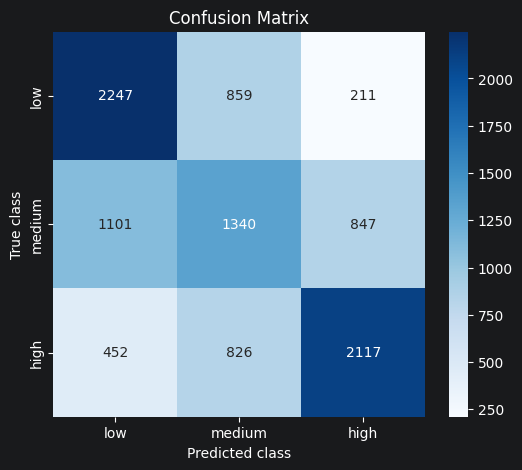

In [121]:
# Visualisierung für Erste Ergebnisse

labels = ["low", "medium", "high"]

cm_50k = confusion_matrix(
    y_test_50k,
    y_pred_50k,
    labels = labels
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_50k,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")

plt.show()

## Results

### First Classification Results

The baseline Logistic Regression classifier achieved an overall accuracy of 57%.

The model performed best on the high and low intensity classes, reaching F1-scores of 0.64 and 0.63 respectively.

The medium intensity class was more difficult to classify (F1-score = 0.42), likely because reviews with moderate emotional intensity share characteristics with both low- and high-intensity reviews.

Overall, the results indicate that emotional intensity can be predicted from review text better than random guessing, while leaving room for further model improvements.


In [122]:
results_50k = pd.DataFrame({
    "reviewText": X_test.copy,
    "actual": y_test_50k,
    "predicted": y_pred_50k
})

results_50k.to_csv(
    "../Dataset/classification_predictions_50k.csv",
    index=False
)

# Model Improvement Experiments

## Experiment 1. Baseline 100k
Logistic Regression
100 000 Reviews

### Optional. Generate Emotion Scores
Falls die Datei *_with_emotions.csv bereits existiert, muss der Block nicht ausgeführt werden.

In [61]:
#die Emotionen für die gesamte Stichprobe.
emotion_scores_100k = classification_sample_100k["reviewText"].apply(get_emotion_scores)

#Frame
emotion_scores_100k_df = pd.DataFrame(emotion_scores_100k.tolist())

In [123]:
#Concatination classification_sample_100k mit emotions
classification_sample_100k = pd.concat(
    [
        classification_sample_100k.reset_index(drop=True),
        emotion_scores_100k_df.reset_index(drop=True)
    ],
    axis=1
)
classification_sample_100k.shape

(100000, 30)

In [124]:
classification_sample_100k.to_csv(
    "../Dataset/classification_sample_100k_with_emotions.csv",
    index=False
)
print("Classification dataset für 100k saved.")

Classification dataset für 100k saved.


### Dataset

In [125]:
classification_sample_100k = pd.read_csv(
    "../Dataset/classification_sample_100k_with_emotions.csv"
)

# Datensatz für dieses Experiment
data = classification_sample_100k
experiment_name = "100k Sample"

### Train-Test Split

In [126]:
# Zielvariable (Emotionale Intensität (1 − Neutral-Score))

y_intensity = 1 - data["neutral"]

# Texte

X = data["reviewText"]

# Train-Test-Split

X_train, X_test, y_intensity_train, y_intensity_test = train_test_split(
    X,
    y_intensity,
    test_size=0.2,
    random_state=RANDOM_STATE
)
# Quantilgrenzen bestimmen

# Die Quantilgrenzen werden ausschließlich
# auf dem Trainingsdatensatz berechnet.

q1 = y_intensity_train.quantile(1 / 3)
q2 = y_intensity_train.quantile(2 / 3)

print("Untere Grenze:", q1)
print("Obere Grenze:", q2)


# Zielklassen erzeugen

# Einteilung der emotionalen Intensität
# in drei Klassen anhand der Trainingsquantile.

def assign_intensity_class(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"


# Klassen für Train und Test erstellen

# Die gleichen Schwellenwerte werden sowohl
# auf den Trainings- als auch auf den Testdatensatz angewendet.

y_train = y_intensity_train.apply(assign_intensity_class)
y_test = y_intensity_test.apply(assign_intensity_class)
# Klassenverteilung kontrollieren

# Kontrolle der Klassenverteilung
# im Trainings- und Testdatensatz.

print("Trainingsdaten:")
print(y_train.value_counts())

print()

print("Testdaten:")
print(y_test.value_counts())

Untere Grenze: 0.46364500125249225
Obere Grenze: 0.8910881007711092
Trainingsdaten:
neutral
high      26667
low       26667
medium    26666
Name: count, dtype: int64

Testdaten:
neutral
high      6698
medium    6692
low       6610
Name: count, dtype: int64


### TF-IDF

In [127]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### Logistic Regression & ML & Vorhersage

In [128]:
model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model.fit(X_train_tfidf, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [129]:
# Vorhersage der Intensitätsklassen
# für die bisher ungesehenen Testdaten.

y_pred = model.predict(
    X_test_tfidf
)

### Evaluation

In [130]:
y_test_100k = y_test.copy()
y_pred_100k = y_pred.copy()

In [131]:
print(classification_report(y_test_100k, y_pred_100k))

              precision    recall  f1-score   support

        high       0.69      0.64      0.66      6698
         low       0.60      0.71      0.65      6610
      medium       0.47      0.42      0.45      6692

    accuracy                           0.59     20000
   macro avg       0.59      0.59      0.59     20000
weighted avg       0.59      0.59      0.59     20000



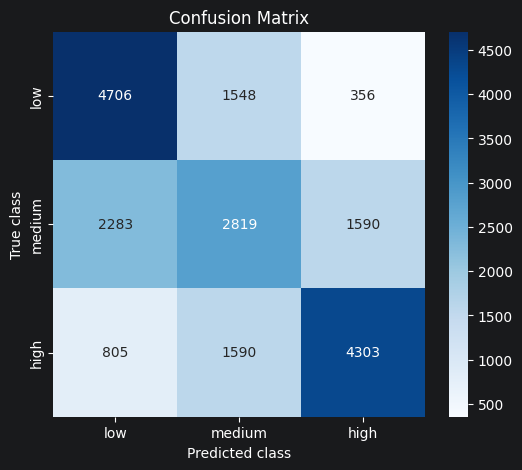

In [132]:
# Visualisierung für Ergebnisse

labels = ["low", "medium", "high"]

cm_100k = confusion_matrix(
    y_test_100k,
    y_pred_100k,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_100k,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")

plt.show()

### Results

Die Vergrößerung der Stichprobe von 50.000 auf 100.000 Reviews führte nur zu einer geringen Verbesserung der Accuracy (57 % → 59 %). Dies deutet darauf hin, dass die Hauptschwierigkeit nicht in der Datenmenge liegt, sondern in der Abgrenzung der Klasse „medium“, die deutlich schwieriger zu klassifizieren ist als „low“ und „high“.

In [133]:
results_100k = pd.DataFrame({
    "reviewText": X_test.copy,
    "actual": y_test_100k,
    "predicted": y_pred_100k
})

results_100k.to_csv(
    "../Dataset/classification_predictions_100k.csv",
    index=False
)

### Weitere Untersuchungen zu den Ergebnissen

In [134]:
# Logistic Regression.Top Words
feature_names = vectorizer.get_feature_names_out()
len(feature_names)

10000

In [135]:
model.classes_

array(['high', 'low', 'medium'], dtype=object)

In [138]:
# HIGH
high_idx = list(model.classes_).index("high")

high_words = pd.DataFrame({
    "word": feature_names,
    "coef": model.coef_[high_idx]
})

high_words.sort_values(
    "coef",
    ascending=False
).head(20)

,word,coef
4288,horror,8.033367
9920,worst,6.617999
8723,surprising,6.560564
7643,sadly,6.102063
7638,sad,5.776226
3165,exhilarating,5.752689
9918,worse,5.702693
3014,entertaining,5.680794
2989,enjoyable,5.466726
4108,haunting,5.394596


In [ ]:
"""
Die Analyse der wichtigsten TF-IDF-Merkmale zeigte, dass die Klassifikation nicht ausschließlich auf emotionalen Wörtern basiert. Neben emotional geprägten Begriffen wie frightening, harrowing oder worrying wurden auch thematische Wörter und Eigennamen als wichtige Merkmale identifiziert. Dies verdeutlicht eine typische Eigenschaft von TF-IDF-basierten Modellen: Sie lernen statistische Zusammenhänge zwischen Wörtern und Klassen, ohne deren semantische Bedeutung zu verstehen.
"""

In [139]:
# LOW
low_idx = list(model.classes_).index("low")

low_words = pd.DataFrame({
    "word": feature_names,
    "coef": model.coef_[low_idx]
})

low_words.sort_values(
    "coef",
    ascending=False
).head(20)

,word,coef
5709,minimum,1.901364
2458,different,1.729963
5977,needs,1.710219
4690,intrigued,1.705301
4058,hang,1.648098
881,better,1.571723
4236,hoffman,1.553735
4625,instead,1.525601
4756,isn,1.474105
854,belong,1.438884


In [140]:
# MEDIUM
medium_idx = list(model.classes_).index("medium")

medium_words = pd.DataFrame({
    "word": feature_names,
    "coef": model.coef_[medium_idx]
})

medium_words.sort_values(
    "coef",
    ascending=False
).head(20)

,word,coef
9402,unfortunately,2.285106
3705,funny,2.228361
717,awkward,1.794331
3588,forgettable,1.691804
3679,frustrating,1.606863
6599,pity,1.577044
3289,fails,1.565942
2506,disappointed,1.558506
9394,unflinching,1.555508
403,amazing,1.536894


### Evaluation_Additional
Die Analyse der wichtigsten TF-IDF-Merkmale zeigte einen klaren Unterschied zwischen den Klassen mit niedriger und hoher Emotionsintensität.

Die mittlere Klasse war dagegen weniger eindeutig. Sie enthielt eine Mischung aus positiven, negativen und neutralen Begriffen. Das deutet darauf hin, dass diese Klasse eher einen Übergangsbereich darstellt als eine klar abgrenzbare Kategorie.

Dies erklärt auch, warum die mittlere Klasse schwieriger zu klassifizieren ist und einen niedrigeren F1-Score erzielt hat als die Klassen mit niedriger oder hoher Intensität.

## Experiment 2. Baseline 500k
Logistic Regression
500 000 Reviews

### Optional. Generate Emotion Scores
Falls die Datei *_with_emotions.csv bereits existiert, muss der Block nicht ausgeführt werden.

In [82]:
#die Emotionen für die gesamte Stichprobe.
emotion_scores_500k = classification_sample_500k["reviewText"].apply(get_emotion_scores)

#Frame
emotion_scores_500k_df = pd.DataFrame(emotion_scores_500k.tolist())

In [83]:
#Concatination classification_sample_500k mit emotions
classification_sample_500k = pd.concat(
    [
        classification_sample_500k.reset_index(drop=True),
        emotion_scores_500k_df.reset_index(drop=True)
    ],
    axis=1
)
classification_sample_500k.shape

(500000, 21)

In [84]:
classification_sample_500k.to_csv(
    "../Dataset/classification_sample_500k_with_emotions.csv",
    index=False
)
print("Classification dataset für 500k saved.")

Classification dataset für 500k saved.


### Dataset

In [85]:
classification_sample_500k = pd.read_csv(
    "../Dataset/classification_sample_500k_with_emotions.csv"
)

# Datensatz für dieses Experiment
data = classification_sample_500k
# experiment_name = "500k Sample"

### Train-Test Split

In [87]:
# Zielvariable (Emotionale Intensität (1 − Neutral-Score))

y_intensity = 1 - data["neutral"]

# Texte

X = data["reviewText"]

# Train-Test-Split

X_train, X_test, y_intensity_train, y_intensity_test = train_test_split(
    X,
    y_intensity,
    test_size=0.2,
    random_state=RANDOM_STATE
)
# Quantilgrenzen bestimmen

# Die Quantilgrenzen werden ausschließlich
# auf dem Trainingsdatensatz berechnet.

q1 = y_intensity_train.quantile(1 / 3)
q2 = y_intensity_train.quantile(2 / 3)

print("Untere Grenze:", q1)
print("Obere Grenze:", q2)


# Zielklassen erzeugen

# Einteilung der emotionalen Intensität
# in drei Klassen anhand der Trainingsquantile.

def assign_intensity_class(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"


# Klassen für Train und Test erstellen

# Die gleichen Schwellenwerte werden sowohl
# auf den Trainings- als auch auf den Testdatensatz angewendet.

y_train = y_intensity_train.apply(assign_intensity_class)
y_test = y_intensity_test.apply(assign_intensity_class)
# Klassenverteilung kontrollieren

# Kontrolle der Klassenverteilung
# im Trainings- und Testdatensatz.

print("Trainingsdaten:")
print(y_train.value_counts())

print()

print("Testdaten:")
print(y_test.value_counts())

Untere Grenze: 0.46049219369888306
Obere Grenze: 0.8896008506417274
Trainingsdaten:
neutral
low       133334
medium    133333
high      133333
Name: count, dtype: int64

Testdaten:
neutral
high      33417
medium    33372
low       33211
Name: count, dtype: int64


### TF-IDF

In [88]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### Logistic Regression & ML & Vorhersage

In [89]:
model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model.fit(X_train_tfidf, y_train)

# Vorhersage der Intensitätsklassen
# für die bisher ungesehenen Testdaten.

y_pred = model.predict(
    X_test_tfidf
)

### Evaluation

In [90]:
y_test_500k = y_test.copy()
y_pred_500k = y_pred.copy()

In [91]:
print(classification_report(y_test_500k, y_pred_500k))

              precision    recall  f1-score   support

        high       0.73      0.66      0.69     33417
         low       0.64      0.76      0.69     33211
      medium       0.51      0.45      0.48     33372

    accuracy                           0.62    100000
   macro avg       0.62      0.62      0.62    100000
weighted avg       0.62      0.62      0.62    100000



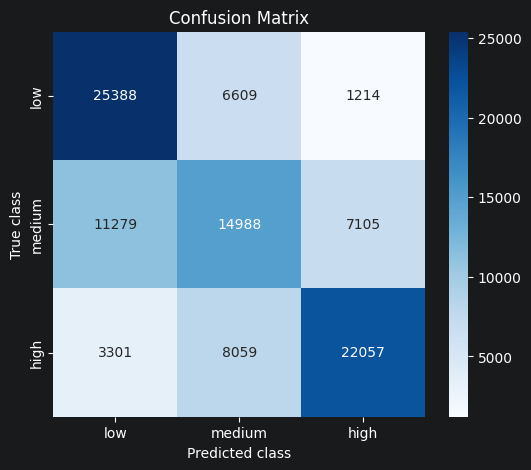

In [92]:
# Visualisierung für Ergebnisse

labels = ["low", "medium", "high"]

cm_500k = confusion_matrix(
    y_test_500k,
    y_pred_500k,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_500k,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")

plt.show()

### Results

Die Vergrößerung der Stichprobe von 50.000 auf 500.000 Reviews führte nur zu einer geringen Verbesserung der Accuracy (57 % → 59 %). Dies deutet darauf hin, dass die Hauptschwierigkeit nicht in der Datenmenge liegt, sondern in der Abgrenzung der Klasse „medium“, die deutlich schwieriger zu klassifizieren ist als „low“ und „high“.

In [93]:
results_500k = pd.DataFrame({
    "reviewText": X_test.copy,
    "actual": y_test_500k,
    "predicted": y_pred_500k
})

results_500k.to_csv(
    "../Dataset/classification_predictions_500k.csv",
    index=False
)

## Experiment 3. Baseline Full Set
Logistic Regression
All Reviews (1 323 533)

### Optional. Generate Emotion Scores
Falls die Datei *_with_emotions.csv bereits existiert, muss der Block nicht ausgeführt werden.

In [143]:
#die Emotionen für alle Daten.

emotion_scores_full = (
    classification_full["reviewText"]
    .apply(get_emotion_scores)
)
emotion_scores_full_df = pd.DataFrame(
    emotion_scores_full.tolist()
)

In [144]:
#Concatination classification_full mit emotions
classification_full = pd.concat(
    [
        classification_full.reset_index(drop=True),
        emotion_scores_full_df.reset_index(drop=True)
    ],
    axis=1
)
classification_full.shape

(1323533, 21)

In [145]:
classification_full.to_csv(
    "../Dataset/classification_full_with_emotions.csv",
    index=False
)
print("Classification dataset für full set saved.")

Classification dataset für full set saved.


### Dataset

In [15]:
classification_full = pd.read_csv(
    "../Dataset/classification_full_with_emotions.csv"
)

# Datensatz für dieses Experiment
data = classification_full
# experiment_name = "full set"

### Train-Test Split

In [147]:
# Zielvariable (Emotionale Intensität (1 − Neutral-Score))

y_intensity = 1 - data["neutral"]

# Texte

X = data["reviewText"]

# Train-Test-Split

X_train, X_test, y_intensity_train, y_intensity_test = train_test_split(
    X,
    y_intensity,
    test_size=0.2,
    random_state=RANDOM_STATE
)
# Quantilgrenzen bestimmen

# Die Quantilgrenzen werden ausschließlich
# auf dem Trainingsdatensatz berechnet.

q1 = y_intensity_train.quantile(1 / 3)
q2 = y_intensity_train.quantile(2 / 3)

print("Untere Grenze:", q1)
print("Obere Grenze:", q2)


# Zielklassen erzeugen

# Einteilung der emotionalen Intensität
# in drei Klassen anhand der Trainingsquantile.

def assign_intensity_class(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"


# Klassen für Train und Test erstellen

# Die gleichen Schwellenwerte werden sowohl
# auf den Trainings- als auch auf den Testdatensatz angewendet.

y_train = y_intensity_train.apply(assign_intensity_class)
y_test = y_intensity_test.apply(assign_intensity_class)
# Klassenverteilung kontrollieren

# Kontrolle der Klassenverteilung
# im Trainings- und Testdatensatz.

print("Trainingsdaten:")
print(y_train.value_counts())

print()

print("Testdaten:")
print(y_test.value_counts())

Untere Grenze: 0.461640973885854
Obere Grenze: 0.8899829636017481
Trainingsdaten:
neutral
high      352942
low       352942
medium    352942
Name: count, dtype: int64

Testdaten:
neutral
low       88392
high      88317
medium    87998
Name: count, dtype: int64


### TF-IDF

In [148]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### Logistic Regression & ML & Vorhersage

In [149]:
model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model.fit(X_train_tfidf, y_train)

# Vorhersage der Intensitätsklassen
# für die bisher ungesehenen Testdaten.

y_pred = model.predict(
    X_test_tfidf
)

### Evaluation

In [150]:
y_test_full = y_test.copy()
y_pred_full = y_pred.copy()

In [151]:
print(classification_report(y_test_full, y_pred_full))

              precision    recall  f1-score   support

        high       0.74      0.66      0.70     88317
         low       0.65      0.78      0.71     88392
      medium       0.51      0.46      0.49     87998

    accuracy                           0.64    264707
   macro avg       0.63      0.63      0.63    264707
weighted avg       0.63      0.64      0.63    264707



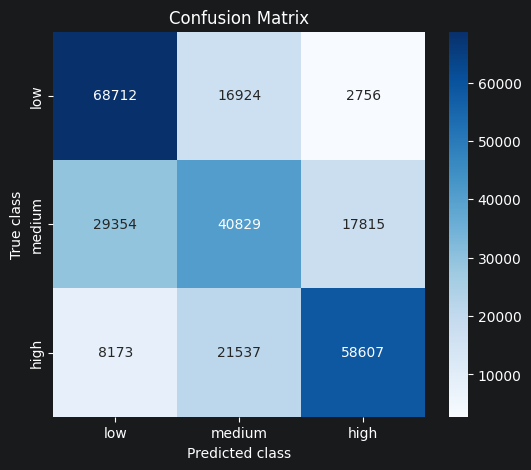

In [152]:
# Visualisierung für Ergebnisse

labels = ["low", "medium", "high"]

cm_full = confusion_matrix(
    y_test_full,
    y_pred_full,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_full,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")

plt.show()

### Results

#### Einfluss der Datensatzgröße

Zur Untersuchung des Einflusses der Datenmenge wurde das Modell auf drei Datensätzen trainiert: 100.000, 500.000 und 1,32 Millionen Reviews.

Die Genauigkeit stieg von 57 % auf 64 %, was zeigt, dass zusätzliche Trainingsdaten die Modellleistung verbessern.

Gleichzeitig blieb die Klasse "medium" deutlich schwieriger zu klassifizieren als die Klassen "low" und "high". Selbst beim größten Datensatz erreichte die Medium-Klasse nur einen F1-Score von 0,49.

Dies deutet darauf hin, dass die Herausforderung nicht ausschließlich auf eine begrenzte Datenmenge zurückzuführen ist, sondern auch auf die inhärente Mehrdeutigkeit der Medium-Klasse.

In [153]:
results_full = pd.DataFrame({
    "reviewText": X_test.copy,
    "actual": y_test_full,
    "predicted": y_pred_full
})

results_full.to_csv(
    "../Dataset/classification_predictions_full.csv",
    index=False
)

## Experiment 4. Fixed Threshold Intensity Classes
In diesem Experiment wird eine alternative Definition der Zielvariable getestet.

Statt die emotionale Intensität über Quantile in drei gleich große Gruppen einzuteilen, werden feste Schwellenwerte verwendet:
- low: 0.00–0.33
- medium: 0.34–0.67
- high: 0.68–1.00

Diese Definition ist intuitiv interpretierbar, kann aber zu unausgewogenen Klassen führen.

### Emotionale Intensität berechnen

Für dieses Experiment wird die emotionale Intensität erneut als
`emotion_intensity = 1 − neutral` definiert. Anschließend werden feste Schwellenwerte verwendet, um drei Klassen zu erzeugen.

In [155]:
# Emotionale Intensität berechnen
# Die Intensität wird als Gegenstück zum Neutral-Score definiert.

data = classification_full.copy()

data["emotional_intensity"] = (
    1 - data["neutral"]
)

# Feste Schwellenwerte definieren

def classify_intensity(x):
    if x <= 0.33:
        return "low"
    elif x <= 0.67:
        return "medium"
    else:
        return "high"

# Zielklassen erzeugen

data["emotion_intensity_class"] = (
    data["emotional_intensity"]
    .apply(classify_intensity)
)

data["emotion_intensity_class"].value_counts(normalize=True)

emotion_intensity_class
high      0.540900
low       0.256211
medium    0.202889
Name: proportion, dtype: float64

### ML

In [156]:
X_fixed = data["reviewText"]
y_fixed = data["emotion_intensity_class"]

X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed = train_test_split(
    X_fixed,
    y_fixed,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_fixed
)

vectorizer_fixed = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_fixed_tfidf = vectorizer_fixed.fit_transform(X_train_fixed)
X_test_fixed_tfidf = vectorizer_fixed.transform(X_test_fixed)

model_fixed = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_fixed.fit(X_train_fixed_tfidf, y_train_fixed)

y_pred_fixed = model_fixed.predict(X_test_fixed_tfidf)

print(classification_report(y_test_fixed, y_pred_fixed))

              precision    recall  f1-score   support

        high       0.74      0.87      0.80    143180
         low       0.59      0.74      0.65     67821
      medium       0.38      0.09      0.15     53706

    accuracy                           0.68    264707
   macro avg       0.57      0.57      0.53    264707
weighted avg       0.63      0.68      0.63    264707



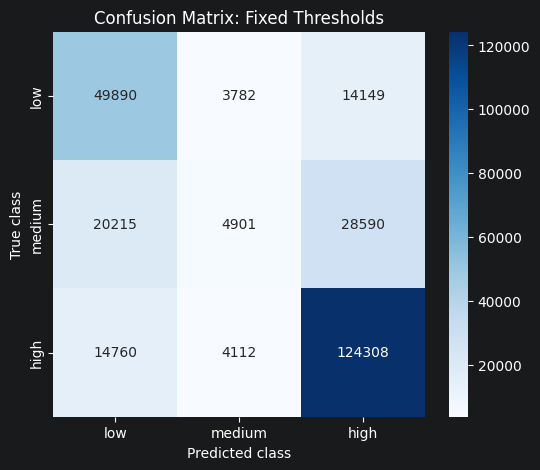

In [157]:
labels = ["low", "medium", "high"]

cm_fixed = confusion_matrix(
    y_test_fixed,
    y_pred_fixed,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_fixed,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix: Fixed Thresholds")
plt.show()

### Evaluation. Feste Schwellenwerte

Zwei Ansätze zur Definition der Zielvariable wurden untersucht: feste Schwellenwerte und Quantile.
Obwohl feste Schwellenwerte eine höhere Accuracy erzielten (68 %), führte die starke Klassenungleichheit zu einer deutlich schlechteren Erkennung der Klasse “medium” mit Macro F1 0.53.

Damit zeigt dieses Experiment, dass Accuracy allein für die Bewertung nicht ausreicht. Für den Vergleich der Modelle ist Macro F1 aussagekräftiger, da alle Klassen gleich gewichtet werden.

Aus diesem Grund ist der quantilbasierte Ansatz für die Baseline geeigneter: Er erzeugt ausgeglichenere Klassen und erlaubt eine fairere Bewertung der Modellleistung.

## Experiment 5. Binary Classification: Low vs High

"extreme groups approach"

In diesem Experiment wird die mittlere Klasse `medium` entfernt.

Ziel ist es zu prüfen, ob die Extremgruppen `low` und `high` deutlich besser voneinander unterscheidbar sind als die drei Klassen im vollständigen Klassifikationsproblem.

Die Quantilgrenzen werden wie in den vorherigen Baseline-Experimenten ausschließlich auf dem Trainingsdatensatz bestimmt, um Data Leakage zu vermeiden.

### Datensatz & Train-Test Split

In [158]:
# Datensatz für das Binary-Experiment

data = classification_full.copy()

# Zielvariable: emotionale Intensität als 1 - neutral
y_intensity = 1 - data["neutral"]

# Texte
X = data["reviewText"]

# Train-Test-Split vor der Klassenerstellung
X_train, X_test, y_intensity_train, y_intensity_test = train_test_split(
    X,
    y_intensity,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [159]:
# Quantilgrenzen ausschließlich auf dem Trainingsdatensatz bestimmen

q1 = y_intensity_train.quantile(1 / 3)
q2 = y_intensity_train.quantile(2 / 3)

print("Untere Grenze:", q1)
print("Obere Grenze:", q2)

Untere Grenze: 0.461640973885854
Obere Grenze: 0.8899829636017481


In [160]:
# Zielklassen erzeugen

def assign_intensity_class(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"


y_train_all = y_intensity_train.apply(assign_intensity_class)
y_test_all = y_intensity_test.apply(assign_intensity_class)

In [161]:
# Nur die Extremklassen low und high behalten

train_mask = y_train_all.isin(["low", "high"])
test_mask = y_test_all.isin(["low", "high"])

X_train_binary = X_train[train_mask]
X_test_binary = X_test[test_mask]

y_train_binary = y_train_all[train_mask]
y_test_binary = y_test_all[test_mask]

In [162]:
# Check
print("Train:")
print(y_train_binary.value_counts(normalize=True))

print("\nTest:")
print(y_test_binary.value_counts(normalize=True))

Train:
neutral
high    0.5
low     0.5
Name: proportion, dtype: float64

Test:
neutral
low     0.500212
high    0.499788
Name: proportion, dtype: float64


### TF-IDF & Logistic Regression & Prediction

In [163]:
vectorizer_binary = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_binary_tfidf = vectorizer_binary.fit_transform(X_train_binary)
X_test_binary_tfidf = vectorizer_binary.transform(X_test_binary)

In [164]:
model_binary = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_binary.fit(
    X_train_binary_tfidf,
    y_train_binary
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [165]:
y_pred_binary = model_binary.predict(X_test_binary_tfidf)

print(
    classification_report(
        y_test_binary,
        y_pred_binary
    )
)

              precision    recall  f1-score   support

        high       0.90      0.83      0.87     88317
         low       0.84      0.91      0.88     88392

    accuracy                           0.87    176709
   macro avg       0.87      0.87      0.87    176709
weighted avg       0.87      0.87      0.87    176709



### Evaluation

Die Ergebnisse des Extreme-Groups-Ansatzes zeigen, dass Reviews mit niedriger und hoher emotionaler Intensität sehr gut voneinander unterschieden werden können (Accuracy = 87 %).

Das Binary-Experiment zeigt, dass die Extremklassen `low` und `high` deutlich besser voneinander unterschieden werden können als die drei Klassen im ursprünglichen Klassifikationsproblem.

Dies bestätigt die Annahme, dass die Klasse `medium` die größte Herausforderung darstellt. Sie bildet vermutlich keine klar abgrenzbare Kategorie, sondern eher einen Übergangsbereich zwischen neutralen und stark emotionalen Reviews.

Wichtig ist, dass dieses Ergebnis nicht direkt mit den Drei-Klassen-Experimenten vergleichbar ist, da die Klasse `medium` hier bewusst entfernt wurde. Das Experiment dient daher vor allem als diagnostischer Test.

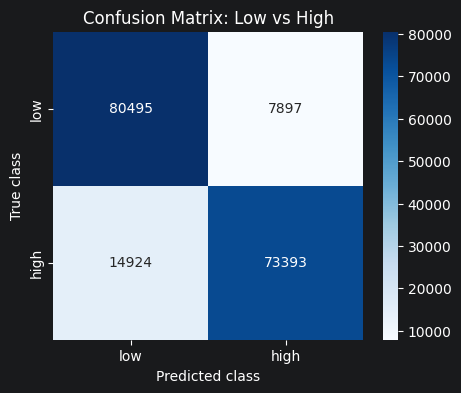

In [166]:
labels_binary = ["low", "high"]

cm_binary = confusion_matrix(
    y_test_binary,
    y_pred_binary,
    labels=labels_binary
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_binary,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_binary,
    yticklabels=labels_binary
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix: Low vs High")

plt.show()

## Experiment 6. Cleaner TF-IDF Features

Die Idee besteht darin, Störmerkmale aus TF-IDF zu entfernen, die nicht direkt die Emotionalität widerspiegeln.

### Exploratory Feature Checks

Vor der Änderung der TF-IDF-Repräsentation haben wir kurz geprüft, ob sich einfache Oberflächenmerkmale wie Ausrufezeichen oder die Länge von Rezensionen zwischen den Intensitätsgruppen unterscheiden.

Diese Merkmale wurden nicht direkt im endgültigen Modell verwendet, halfen uns aber zu verstehen, ob sich emotionale Intensität in einfachen Texteigenschaften widerspiegelt.

In [5]:
data_analysis = classification_full.copy()
data_analysis["emotional_intensity"] = 1 - data_analysis["neutral"]

data_analysis["intensity_group_exploratory"] = pd.qcut(
    data_analysis["emotional_intensity"],
    q=3,
    labels=["low", "medium", "high"]
)

#### Exclamation marks

Rezensionen mit hoher emotionaler Intensität enthielten etwa dreimal häufiger Ausrufezeichen als solche mit geringer emotionaler Intensität. Die Gesamthäufigkeit von Ausrufezeichen war jedoch sehr gering (< 2 % der Rezensionen), was ihren Nutzen als prädiktives Merkmal einschränkte.

In [6]:
data_analysis["exclamation_count"] = (
    data_analysis["reviewText"]
    .str.count("!")
)

data_analysis.groupby(
    "intensity_group_exploratory"
)["exclamation_count"].mean()

intensity_group_exploratory
low       0.004148
medium    0.013387
high      0.018342
Name: exclamation_count, dtype: float64

#### Word Count

Interpretation der Wortanzahl

Die Analyse zeigte nur sehr geringe Unterschiede in der durchschnittlichen Länge der Rezensionen zwischen den Intensitätsklassen.

| Klasse | Durchschnittliche Wortanzahl |
|---------|------------------------------|
| Low | 22.84                        |
| Medium | 22.31                        |
| High | 21.57                        |

Entgegen der ursprünglichen Annahme sind emotional intensivere Rezensionen nicht länger als weniger emotionale Rezensionen.

Dies deutet darauf hin, dass emotionale Intensität hauptsächlich durch die Wortwahl und nicht durch die Länge einer Rezension ausgedrückt wird. Die Wortanzahl scheint daher kein geeignetes Merkmal zur Verbesserung der Klassifikation zu sein.

In [7]:
data_analysis.groupby(
    "intensity_group_exploratory"
)["word_count"].mean()

intensity_group_exploratory
low       22.839344
medium    22.307165
high      21.573383
Name: word_count, dtype: float64

### Cleaner TF-IDF Experiment

In diesem Experiment verwendet das Modell eine restriktivere TF-IDF-Repräsentation.

Im Vergleich zur Baseline entfernt der Vektorisierer:
- numerische Token;
- Sonderzeichen;
- sehr kurze Token;
- seltene Wörter, die in weniger als fünf Dokumenten vorkommen.

Die Zielvariable und die Aufteilung in Trainings- und Testdaten bleiben gegenüber der Baseline des vollständigen Datensatzes unverändert. Dies ermöglicht einen direkten Vergleich mit dem vorherigen Baseline-Modell.

#### Datensatz & Train-Test Split

In [12]:
# Datensatz für dieses Experiment

data = classification_full.copy()

# Zielvariable: emotionale Intensität
# Wir definieren sie als Gegenstück zum Neutral-Score.
y_intensity = 1 - data["neutral"]

# Texte als Eingabedaten
X = data["reviewText"]

# Train-Test-Split vor der Klassenerstellung,
# um Data Leakage zu vermeiden.
X_train, X_test, y_intensity_train, y_intensity_test = train_test_split(
    X,
    y_intensity,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [13]:
# Quantilgrenzen ausschließlich auf dem Trainingsdatensatz bestimmen

q1 = y_intensity_train.quantile(1 / 3)
q2 = y_intensity_train.quantile(2 / 3)

print("Untere Grenze:", q1)
print("Obere Grenze:", q2)

Untere Grenze: 0.461640973885854
Obere Grenze: 0.8899829636017481


In [14]:
# Zielklassen anhand der Trainingsquantile erzeugen

def assign_intensity_class(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"


y_train = y_intensity_train.apply(assign_intensity_class)
y_test = y_intensity_test.apply(assign_intensity_class)

In [15]:
# Kontrolle der Klassenverteilung

print("Trainingsdaten:")
print(y_train.value_counts(normalize=True))

print("\nTestdaten:")
print(y_test.value_counts(normalize=True))

Trainingsdaten:
neutral
high      0.333333
low       0.333333
medium    0.333333
Name: proportion, dtype: float64

Testdaten:
neutral
low       0.333924
high      0.333641
medium    0.332435
Name: proportion, dtype: float64


#### TF-IDF & Logistic Regression & Prediction

In [16]:
# Cleaner TF-IDF:
# Im Vergleich zur Baseline werden nur alphabetische Tokens
# mit mindestens drei Zeichen berücksichtigt.
# Zusätzlich werden sehr seltene Wörter entfernt.

vectorizer_clean = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words),
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
    min_df=5
)

In [17]:
# TF-IDF-Vektorisierung
# fit_transform nur auf den Trainingsdaten,
# transform auf den Testdaten.

X_train_tfidf_clean = vectorizer_clean.fit_transform(X_train)
X_test_tfidf_clean = vectorizer_clean.transform(X_test)

In [18]:
# Logistische Regression

model_clean = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_clean.fit(
    X_train_tfidf_clean,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [19]:
# Vorhersage auf den Testdaten

y_pred_clean = model_clean.predict(X_test_tfidf_clean)

In [20]:
# Evaluation

print(
    classification_report(
        y_test,
        y_pred_clean
    )
)

              precision    recall  f1-score   support

        high       0.72      0.64      0.68     88317
         low       0.64      0.77      0.70     88392
      medium       0.50      0.45      0.48     87998

    accuracy                           0.62    264707
   macro avg       0.62      0.62      0.62    264707
weighted avg       0.62      0.62      0.62    264707



### Evaluation of Cleaner TF-IDF Features

In diesem Experiment wurde die TF-IDF-Darstellung bereinigt, indem numerische Tokens, sehr kurze Tokens und seltene Wörter entfernt wurden.

Die Modellleistung blieb jedoch nahezu unverändert:

| Modell            | Accuracy | Macro F1 |
|-------------------|----------|----------|
| Baseline Full Set | 0.64     | 0.63     |
| Cleaner TF-IDF    | 0.62     | 0.62     |

Das Entfernen numerischer Tokens, kurzer Wörter und seltener Begriffe führte zu keiner Verbesserung der Modellleistung.

Die Accuracy sank von 0.64 auf 0.62, während sich der Macro-F1-Wert von 0.63 auf 0.62 verringerte.

Die Konfusionsmatrix zeigt, dass insbesondere die Klasse **„medium“** weiterhin schwer von den Klassen **„low“** und **„high“** abzugrenzen ist. Die meisten Fehlklassifikationen entstehen innerhalb dieser mittleren Intensitätsstufe.

Die entfernten Merkmale scheinen keine wesentliche Quelle des Rauschens zu sein.

Insgesamt zeigt dieses Experiment, dass die Begrenzung der TF-IDF-Merkmale allein nicht ausreicht, um die Klassifikation emotionaler Intensität zu verbessern.

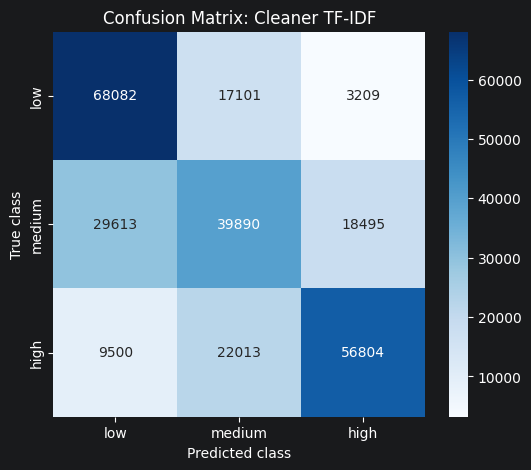

In [21]:
# Confusion Matrix

labels = ["low", "medium", "high"]

cm_clean = confusion_matrix(
    y_test,
    y_pred_clean,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_clean,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix: Cleaner TF-IDF")

plt.show()

## Experiment 7. TF-IDF with Bigrams

In diesem Experiment werden zusätzlich zu einzelnen Wörtern auch Wortpaare (Bigrams) berücksichtigt.

Die Annahme ist, dass emotionale Intensität häufig durch Wortkombinationen wie „very good“, „really bad“ oder „absolutely amazing“ ausgedrückt wird.

Der Vektorisierer verwendet daher sowohl Unigramme als auch Bigramme, während die übrigen Modellkomponenten unverändert bleiben.

Nicht nur: boring, funny, moving, recommend

sondern auch: very boring, not funny, deeply moving, highly recommend

### Datensatz & Train-Test Split

In [22]:
# Datensatz für dieses Experiment

data = classification_full.copy()

# Zielvariable: emotionale Intensität
# Wir definieren sie als Gegenstück zum Neutral-Score.
y_intensity = 1 - data["neutral"]

# Texte als Eingabedaten
X = data["reviewText"]

# Train-Test-Split vor der Klassenerstellung,
# um Data Leakage zu vermeiden.
X_train, X_test, y_intensity_train, y_intensity_test = train_test_split(
    X,
    y_intensity,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [23]:
# Quantilgrenzen ausschließlich auf dem Trainingsdatensatz bestimmen

q1 = y_intensity_train.quantile(1 / 3)
q2 = y_intensity_train.quantile(2 / 3)

print("Untere Grenze:", q1)
print("Obere Grenze:", q2)



Untere Grenze: 0.461640973885854
Obere Grenze: 0.8899829636017481


In [24]:
# Zielklassen anhand der Trainingsquantile erzeugen

def assign_intensity_class(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"


y_train = y_intensity_train.apply(assign_intensity_class)
y_test = y_intensity_test.apply(assign_intensity_class)

### TF-IDF & Logistic Regression & Prediction

In [25]:
# TF-IDF mit Bigrams
vectorizer_bigram = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words),
    ngram_range=(1, 2)
)

In [26]:
# TF-IDF erzeugen
X_train_tfidf_bigram = vectorizer_bigram.fit_transform(X_train)

X_test_tfidf_bigram = vectorizer_bigram.transform(X_test)

In [27]:
# Logistic Regression
model_bigram = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_bigram.fit(
    X_train_tfidf_bigram,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [28]:
# Vorhersage
y_pred_bigram = model_bigram.predict(
    X_test_tfidf_bigram
)

### Evaluation of TF-IDF with Bigrams

Die Berücksichtigung von Bigrams führte zu einer leichten Veränderung der Modellleistung.

Die Accuracy blieb nahezu unverändert, während sich die Klassifikation der Klassen „medium“ und „high“ geringfügig verbesserte.

Die Konfusionsmatrix zeigt, dass mehr Texte der mittleren Intensitätsklasse korrekt erkannt wurden. Gleichzeitig konnten einige Fehlklassifikationen zwischen den Klassen „medium“ und „high“ reduziert werden.

Die Ergebnisse deuten darauf hin, dass Wortkombinationen zusätzliche Informationen über emotionale Intensität enthalten. Ausdrücke wie „very good“ oder „really bad“ können emotionale Signale besser erfassen als einzelne Wörter.

Der Einfluss der Bigrams bleibt jedoch insgesamt begrenzt. Einzelne Wörter liefern bereits einen großen Teil der relevanten Informationen für die Vorhersage der emotionalen Intensität.

Die Verwendung von Bigrams verbessert das Modell daher nur geringfügig und führt zu keiner deutlichen Steigerung der Gesamtleistung.

In [29]:
# Evaluation
print(
    classification_report(
        y_test,
        y_pred_bigram
    )
)

              precision    recall  f1-score   support

        high       0.74      0.66      0.70     88317
         low       0.64      0.77      0.70     88392
      medium       0.51      0.46      0.49     87998

    accuracy                           0.63    264707
   macro avg       0.63      0.63      0.63    264707
weighted avg       0.63      0.63      0.63    264707



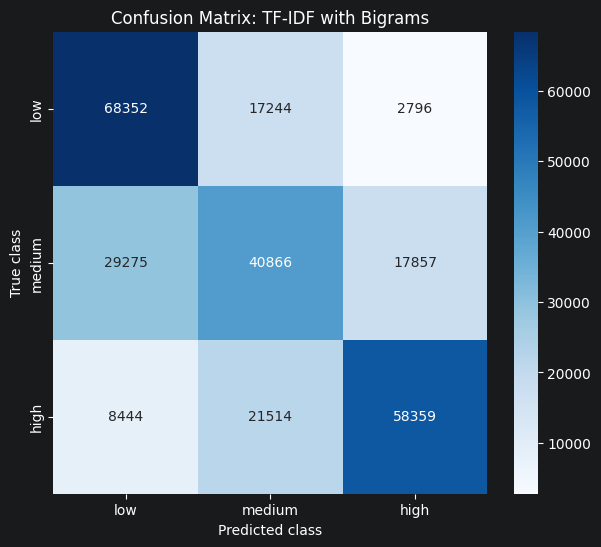

In [30]:
# Confusion Matrix
labels = ["low", "medium", "high"]

cm = confusion_matrix(
    y_test,
    y_pred_bigram,
    labels=labels
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix: TF-IDF with Bigrams")

plt.show()

### Analyse

In [31]:
feature_names_bigram = vectorizer_bigram.get_feature_names_out()

len(feature_names_bigram)

10000

In [32]:
bigrams = [
    feature
    for feature in feature_names_bigram
    if " " in feature
]

len(bigrams)

1870

In [33]:
bigrams[:50]

['10 10',
 '10 minutes',
 '10 years',
 '100 minutes',
 '12 year',
 '15 minutes',
 '19th century',
 '20 minutes',
 '20 years',
 '20th century',
 '21st century',
 '30 minutes',
 '30 years',
 '40 years',
 '41 44',
 '44 44',
 '44 46',
 '44 8217',
 '44 8220',
 '44 8221',
 '44 apos',
 '44 does',
 '44 doesn',
 '44 especially',
 '44 film',
 '44 just',
 '44 more',
 '44 movie',
 '44 never',
 '44 not',
 '44 quot',
 '44 story',
 '46 10',
 '46 44',
 '46 46',
 '46 8217',
 '46 8221',
 '46 91',
 '46 apos',
 '46 film',
 '46 movie',
 '46 not',
 '46 quot',
 '50 years',
 '80 minutes',
 '8217 film',
 '8217 ll',
 '8217 not',
 '8217 ve',
 '90 minute']

In [34]:
coef_high = model_bigram.coef_[0]

top_high = pd.DataFrame({
    "feature": feature_names_bigram,
    "coef": coef_high
})

top_high = top_high[
    top_high["feature"].str.contains(" ")
]

top_high.sort_values(
    "coef",
    ascending=False
).head(20)

,feature,coef
4090,hard believe,3.434119
5340,lot fun,2.870346
697,bad enough,2.554660
3681,fun ride,2.516889
4845,joy watch,2.498100
5767,missed opportunity,2.470217
4881,just bad,2.356901
5184,light hearted,2.343504
3238,feel good,2.313490
6808,pleasure watch,2.303410


In [35]:
coef_medium = model_bigram.coef_[1]
top_medium = pd.DataFrame({
    "feature": feature_names_bigram,
    "coef": coef_medium
})

top_medium = top_medium[
    top_medium["feature"].str.contains(" ")
]

top_medium.sort_values(
    "coef",
    ascending=False
).head(20)

,feature,coef
9862,wonder woman,3.079417
3875,good bad,2.457447
4088,happy ending,2.254926
4132,having fun,2.188079
2448,doctor strange,1.995598
3248,feels like,1.983384
5454,make sure,1.964663
5307,look feel,1.901164
5357,love hate,1.721519
5144,let hope,1.590956


In [36]:
coef_low = model_bigram.coef_[2]
top_low = pd.DataFrame({
    "feature": feature_names_bigram,
    "coef": coef_low
})

top_low = top_low[
    top_low["feature"].str.contains(" ")
]

top_low.sort_values(
    "coef",
    ascending=False
).head(20)

,feature,coef
681,awful lot,1.778514
83,44 46,1.772846
103,46 46,1.662516
82,44 44,1.658177
5845,more enjoyable,1.290582
3889,good news,1.260379
4315,horror comedy,1.186648
6192,no surprise,1.167273
84,44 8217,1.098953
102,46 44,1.093335


#### Analysis of Important Bigrams

Die wichtigsten Bigrams zeigen deutliche Unterschiede zwischen den Klassen.

Die Klasse mit hoher Emotionsintensität enthält stark emotionale Ausdrücke wie „lot fun“, „feel good“ und „very funny“.

Die mittlere Klasse enthält dagegen eher neutrale oder gemischte Ausdrücke wie „just fine“, „needs more“ und „gets right“. Diese Formulierungen drücken häufig keine starke Emotion aus, sondern eine ausgewogene Bewertung.

Dies deutet darauf hin, dass die mittlere Klasse kein eigenes, klar erkennbares Vokabular besitzt. Stattdessen bildet sie einen Übergangsbereich zwischen niedriger und hoher Emotionsintensität.

Diese Beobachtung stimmt mit den vorherigen Experimenten überein. Nachdem die mittlere Klasse entfernt wurde, verbesserte sich die Klassifikationsleistung deutlich (Accuracy = 87 %).

## Experiment 8. Dominant Emotion Based Intensity Classes

In diesem Experiment wird emotionale Intensität nicht über den Neutral-Score bestimmt.

Stattdessen wird die stärkste nicht-neutrale Emotion einer Rezension als Maß für die emotionale Intensität verwendet.

Die Annahme ist, dass sehr starke Einzelemotionen die emotionale Wirkung einer Rezension besser beschreiben als ein niedriger Neutral-Wert.

### Datensatz & Train-Test Split

In [37]:
# Datensatz für dieses Experiment

data_dominant = classification_full.copy()

In [38]:
# Nicht-neutrale Emotionsspalten

emotion_cols_non_neutral = [
    "surprise",
    "joy",
    "sadness",
    "anger",
    "disgust",
    "fear"
]

# Dominante Emotion berechnen
# Für jede Rezension wird der höchste nicht-neutrale Emotionswert verwendet.

data_dominant["dominant_emotion_score"] = (
    data_dominant[emotion_cols_non_neutral]
    .max(axis=1)
)

In [39]:
# Kurzer Überblick über die Verteilung der dominanten Emotion

data_dominant["dominant_emotion_score"].describe()

count    1.323533e+06
mean     4.951110e-01
std      3.226618e-01
min      4.463267e-03
25%      1.849458e-01
50%      4.882982e-01
75%      8.075276e-01
max      9.957730e-01
Name: dominant_emotion_score, dtype: float64

In [40]:
# Zielvariable für dieses Experiment
y_intensity_dominant = data_dominant["dominant_emotion_score"]

# Texte
X_dominant = data_dominant["reviewText"]

# Train-Test-Split vor der Klassenerstellung,
# um Data Leakage zu vermeiden.
X_train_dominant, X_test_dominant, y_intensity_train_dominant, y_intensity_test_dominant = train_test_split(
    X_dominant,
    y_intensity_dominant,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [41]:
# Quantilgrenzen ausschließlich auf dem Trainingsdatensatz bestimmen

q1_dominant = y_intensity_train_dominant.quantile(1 / 3)
q2_dominant = y_intensity_train_dominant.quantile(2 / 3)

print("Untere Grenze:", q1_dominant)
print("Obere Grenze:", q2_dominant)

Untere Grenze: 0.2836735844612121
Obere Grenze: 0.7042831579844155


In [42]:
# Zielklassen anhand der Trainingsquantile erzeugen

def assign_dominant_intensity_class(x):
    if x <= q1_dominant:
        return "low"
    elif x <= q2_dominant:
        return "medium"
    else:
        return "high"

# Die gleichen Schwellenwerte werden auf Train und Test angewendet.

y_train_dominant = y_intensity_train_dominant.apply(assign_dominant_intensity_class)
y_test_dominant = y_intensity_test_dominant.apply(assign_dominant_intensity_class)

In [43]:
# Kontrolle der Klassenverteilung

print("Trainingsdaten:")
print(y_train_dominant.value_counts(normalize=True))

print("\nTestdaten:")
print(y_test_dominant.value_counts(normalize=True))

Trainingsdaten:
dominant_emotion_score
high      0.333333
low       0.333333
medium    0.333333
Name: proportion, dtype: float64

Testdaten:
dominant_emotion_score
high      0.334887
low       0.333656
medium    0.331457
Name: proportion, dtype: float64


### TF-IDF & Logistic Regression & Prediction

In [44]:
# TF-IDF-Vektorisierung
vectorizer_dominant = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)


# fit_transform nur auf den Trainingsdaten,
# transform auf den Testdaten.
X_train_tfidf_dominant = vectorizer_dominant.fit_transform(X_train_dominant)
X_test_tfidf_dominant = vectorizer_dominant.transform(X_test_dominant)

# Logistische Regression
model_dominant = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Modelltraining
model_dominant.fit(
    X_train_tfidf_dominant,
    y_train_dominant
)

# Vorhersage auf den Testdaten
y_pred_dominant = model_dominant.predict(
    X_test_tfidf_dominant
)

### Evaluation of Dominant Emotion Based Intensity Classes

In diesem Experiment wurde die emotionale Intensität nicht über den Neutral-Score, sondern über die stärkste nicht-neutrale Emotion definiert.

Die Annahme war, dass eine dominante Emotion ein stärkeres Signal für emotionale Intensität liefern könnte.

Die Ergebnisse zeigen jedoch eine Verschlechterung der Modellleistung:

| Modell | Accuracy | Macro F1 |
|--------|----------:|---------:|
| Baseline Full Set | 0.64 | 0.63 |
| Dominant Emotion | 0.60 | 0.60 |

Insbesondere die Klasse „high“ wurde deutlich schlechter erkannt. Viele stark emotionale Rezensionen wurden als „medium“ oder sogar als „low“ klassifiziert.

Die Confusion Matrix zeigt außerdem, dass die Klasse „medium“ weiterhin die größte Herausforderung darstellt.

Die Ergebnisse deuten darauf hin, dass emotionale Intensität nicht allein durch die stärkste einzelne Emotion beschrieben werden kann. Die ursprüngliche Definition über den Neutral-Score berücksichtigt dagegen die gesamte emotionale Aktivierung eines Textes und liefert stabilere Ergebnisse.

Dominant Emotion stellt daher keine Verbesserung gegenüber dem Baseline-Modell dar.

In [45]:
# Evaluation
print(
    classification_report(
        y_test_dominant,
        y_pred_dominant
    )
)

              precision    recall  f1-score   support

        high       0.69      0.61      0.65     88647
         low       0.62      0.78      0.69     88321
      medium       0.49      0.42      0.45     87739

    accuracy                           0.60    264707
   macro avg       0.60      0.60      0.60    264707
weighted avg       0.60      0.60      0.60    264707



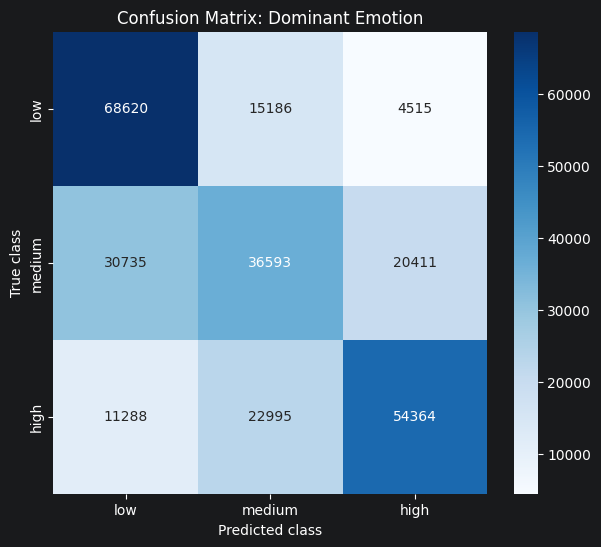

In [46]:
# Confusion Matrix

labels_dominant = ["low", "medium", "high"]

cm_dominant = confusion_matrix(
    y_test_dominant,
    y_pred_dominant,
    labels=labels_dominant
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_dominant,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_dominant,
    yticklabels=labels_dominant
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix: Dominant Emotion")

plt.show()

# Experiment 9. Finales bestes Rule-Based Target
## Idee

Nachdem die vorherigen Experimente gezeigt haben, dass zusätzliche TF-IDF-Bereinigung, Bigrams und eine dominante Einzelemotion die Modellleistung nicht deutlich verbessern, wird in diesem Experiment die Definition der Zielvariable angepasst.

Die zentrale Idee ist, emotionale Intensität stärker über die emotionale Struktur der Modelloutputs zu definieren:

- sehr hoher Neutral-Score → `low`
- sehr hoher Anteil nicht-neutraler Emotionen → `high`
- alle Zwischenfälle → `medium`

Damit wird `medium` bewusst als Übergangsbereich zwischen neutralen und stark emotionalen Rezensionen verstanden.

Wichtig:

Da die Emotionswerte durch Softmax normalisiert sind, gilt:
`Summe aller nicht-neutralen Emotionen = 1 - neutral`

Die Regel verwendet `non_neutral_sum`, weil der Test empirisch so durchgeführt wurde.
Methodisch ist aber zu beachten:

`non_neutral_sum >= 0.92` ist äquivalent zu `neutral <= 0.08`.

## Zielvariable erzeugen

In [17]:
# Datensatz für das finale Rule-Based Target
data_final = classification_full.copy()

In [18]:
# Finale regelbasierte Klassendefinition nur über den Neutral-Score

def classify_structure_final(row):
    if row["neutral"] >= 0.65:
        return "low"
    elif row["neutral"] <= 0.08:
        return "high"
    else:
        return "medium"

In [19]:
data_final["emotion_structure_final"] = (
    data_final.apply(classify_structure_final, axis=1)
)

In [20]:
# Klassenverteilung prüfen

data_final["emotion_structure_final"].value_counts(normalize=True)

emotion_structure_final
medium    0.449262
high      0.282491
low       0.268247
Name: proportion, dtype: float64

In [21]:
# Texte und Zielvariable

X_final = data_final["reviewText"]
y_final = data_final["emotion_structure_final"]

## Überprüfung der Klassenverteilung

Die finale regelbasierte Definition erzeugt eine ausgewogene Klassenverteilung:

- low: 26.8 %
- medium: 44.9 %
- high: 28.2 %

Im Gegensatz zur quantilbasierten Baseline entstehen die Klassen hier nicht durch eine künstliche Aufteilung der Daten, sondern durch inhaltlich interpretierbare Schwellenwerte des Neutral-Scores.

Die Verteilung bleibt dabei ausreichend ausgewogen, sodass alle drei Klassen zuverlässig gelernt werden können.

In [22]:
data_final["emotion_structure_final"].value_counts()

emotion_structure_final
medium    594613
high      373886
low       355034
Name: count, dtype: int64

In [23]:
data_final["emotion_structure_final"].value_counts(normalize=True)

emotion_structure_final
medium    0.449262
high      0.282491
low       0.268247
Name: proportion, dtype: float64

## Train-Test Split

In [24]:
# Train-Test-Split

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_final
)

## TF-IDF

In [25]:
# TF-IDF-Vektorisierung

vectorizer_final = TfidfVectorizer(
    max_features=10000,
    stop_words=list(custom_stop_words)
)

X_train_tfidf_final = vectorizer_final.fit_transform(X_train_final)
X_test_tfidf_final = vectorizer_final.transform(X_test_final)

## Logistische Regression & Vorhersage

In [26]:
# Logistische Regression

model_final = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model_final.fit(
    X_train_tfidf_final,
    y_train_final
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [27]:
# Vorhersage

y_pred_final = model_final.predict(X_test_tfidf_final)

## Evaluation of Final Rule-Based Target

Das finale Rule-Based Target erzielte die beste Gesamtleistung aller untersuchten Ansätze.

| Modell | Accuracy | Macro F1 |
|--------|----------:|---------:|
| Baseline Full Set | 0.64 | 0.63 |
| Cleaner TF-IDF | 0.62 | 0.62 |
| TF-IDF + Bigrams | 0.63 | 0.63 |
| Dominant Emotion | 0.60 | 0.60 |
| Final Rule-Based Target | 0.65 | 0.65 |

Die regelbasierte Definition der Zielvariable führte zu einer besseren Trennung der drei Intensitätsklassen.

Besonders deutlich verbessert sich die Klasse „medium“. Im Gegensatz zur quantilbasierten Baseline stellt sie nun einen inhaltlich interpretierten Übergangsbereich zwischen sehr neutralen und sehr emotionalen Rezensionen dar.

Die Confusion Matrix zeigt außerdem, dass Verwechslungen zwischen „low“ und „high“ nahezu vollständig verschwinden. Die meisten Fehler entstehen nur noch zwischen benachbarten Klassen.

Dies deutet darauf hin, dass die Definition der Zielvariable einen größeren Einfluss auf die Modellleistung besitzt als zusätzliche Änderungen der TF-IDF-Repräsentation.

Das finale Rule-Based Target stellt damit den erfolgreichsten Ansatz dieser Arbeit dar.

In [28]:
# Evaluation

print(
    classification_report(
        y_test_final,
        y_pred_final
    )
)

              precision    recall  f1-score   support

        high       0.75      0.57      0.65     74777
         low       0.65      0.63      0.64     71007
      medium       0.60      0.70      0.65    118923

    accuracy                           0.65    264707
   macro avg       0.67      0.64      0.65    264707
weighted avg       0.66      0.65      0.65    264707



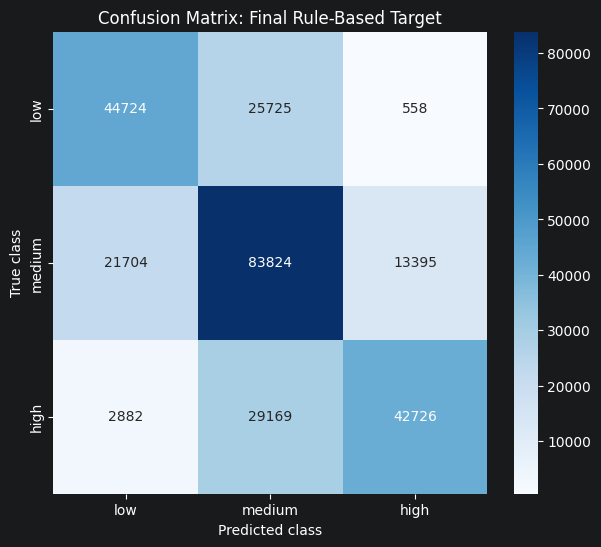

In [29]:
# Confusion Matrix

labels_final = ["low", "medium", "high"]

cm_final = confusion_matrix(
    y_test_final,
    y_pred_final,
    labels=labels_final
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_final,
    yticklabels=labels_final
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix: Final Rule-Based Target")

plt.show()

### Visualisierung

#### Klassenverteilung

Die finale Regeldefinition erzeugt eine relativ ausgewogene Klassenverteilung. Die Klasse „medium“ bildet die größte Gruppe, während „low“ und „high“ ähnliche Anteile aufweisen.

Diese Verteilung reduziert die starke künstliche Gleichverteilung der Quantilansätze und spiegelt die tatsächliche emotionale Struktur der Rezensionen besser wider.

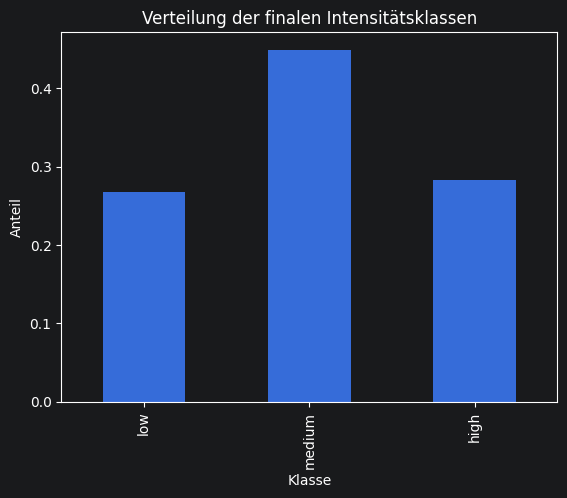

In [32]:
(
    data_final["emotion_structure_final"]
    .value_counts(normalize=True)
    .reindex(["low", "medium", "high"])
    .plot(kind="bar")
)

plt.ylabel("Anteil")
plt.xlabel("Klasse")
plt.title("Verteilung der finalen Intensitätsklassen")

plt.show()

#### Neutral-Score nach Klasse

Der Boxplot zeigt eine klare Trennung der Klassen anhand des Neutral-Scores.

Die Klasse „low“ weist hohe Neutral-Werte auf, während die Klasse „high“ deutlich geringere Neutral-Anteile besitzt. Die Klasse „medium“ liegt erwartungsgemäß zwischen beiden Extremen.

Dies bestätigt, dass der Neutral-Score ein zentrales Merkmal für die Definition emotionaler Intensität darstellt.

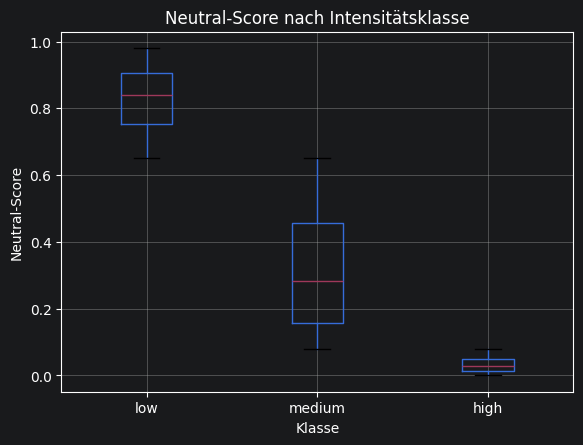

In [33]:
data_final["emotion_structure_final"] = pd.Categorical(
    data_final["emotion_structure_final"],
    categories=["low", "medium", "high"],
    ordered=True
)

data_final.boxplot(
    column="neutral",
    by="emotion_structure_final"
)

plt.title("Neutral-Score nach Intensitätsklasse")
plt.suptitle("")
plt.xlabel("Klasse")
plt.ylabel("Neutral-Score")

plt.show()

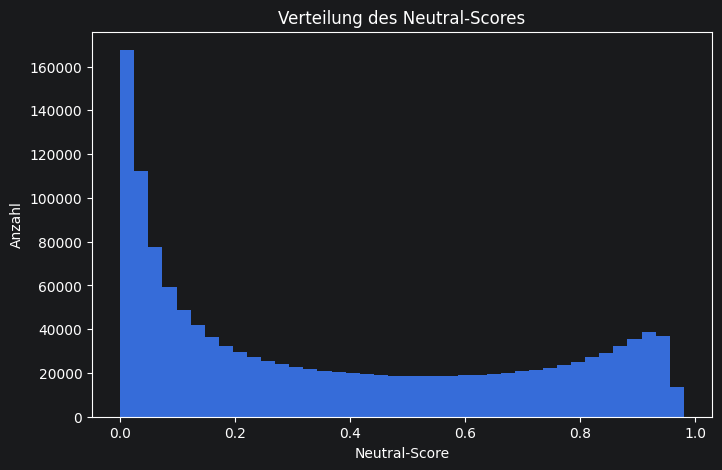

In [63]:
plt.figure(figsize=(8,5))

plt.hist(
    data_final["neutral"],
    bins=40
)

plt.xlabel("Neutral-Score")
plt.ylabel("Anzahl")
plt.title("Verteilung des Neutral-Scores")

plt.show()

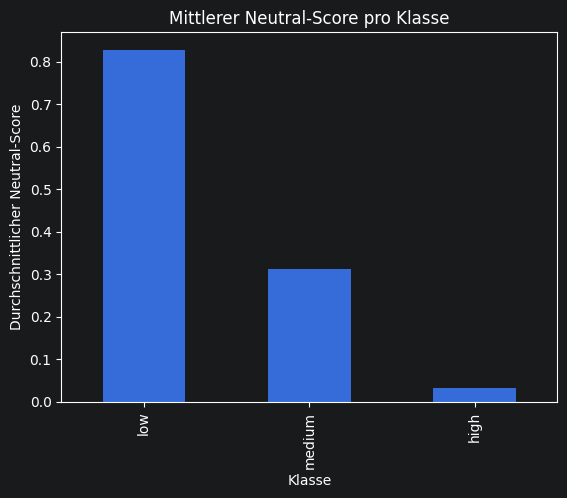

In [34]:
mean_neutral = (
    data_final
    .groupby("emotion_structure_final")["neutral"]
    .mean()
)

# die Ordnung
mean_neutral = mean_neutral.reindex(
    ["low", "medium", "high"]
)
mean_neutral.plot(kind="bar")

plt.ylabel("Durchschnittlicher Neutral-Score")
plt.xlabel("Klasse")
plt.title("Mittlerer Neutral-Score pro Klasse")

plt.show()

#### Interpretation der Neutral-Scores

Die Verteilung des Neutral-Scores zeigt eine deutliche Polarisierung der Rezensionen. Viele Texte weisen entweder sehr hohe oder sehr niedrige Neutralwerte auf, während mittlere Werte seltener auftreten.

Die durchschnittlichen Neutral-Scores unterscheiden sich deutlich zwischen den drei Klassen:

- Die Klasse „low“ besitzt sehr hohe Neutralwerte.
- Die Klasse „high“ weist nahezu keine Neutralität auf.
- Die Klasse „medium“ liegt zwischen beiden Extremen.

Dies bestätigt die zentrale Annahme des Experiments: Der Neutral-Score eignet sich als Indikator für emotionale Intensität.

Die finale regelbasierte Zielvariable basiert damit auf einem interpretierbaren und empirisch nachvollziehbaren Merkmal.

# Dummy Baseline
## Idee

Zur Einordnung der Modellleistung wird zusätzlich eine Dummy-Baseline verwendet.

Der DummyClassifier berücksichtigt weder den Textinhalt noch die TF-IDF-Merkmale. Stattdessen sagt er immer die häufigste Klasse des Trainingsdatensatzes vorher.

Da die Klasse „medium“ im finalen Datensatz am häufigsten vorkommt, gibt die Dummy-Baseline für alle Rezensionen ausschließlich diese Klasse aus.

Die Dummy-Baseline dient als Minimalreferenz, um zu überprüfen, ob das eigentliche Modell tatsächlich Informationen aus den Texten lernt.

In [69]:

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train_tfidf_final,
    y_train_final
)

y_dummy = dummy_model.predict(
    X_test_tfidf_final
)

print(
    classification_report(
        y_test_final,
        y_dummy,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        high       0.00      0.00      0.00     74777
         low       0.00      0.00      0.00     71007
      medium       0.45      1.00      0.62    118923

    accuracy                           0.45    264707
   macro avg       0.15      0.33      0.21    264707
weighted avg       0.20      0.45      0.28    264707



## Ergebnisse der Dummy-Baseline

Die Dummy-Baseline erreicht eine Accuracy von 0.45, da die Klasse „medium“ etwa 45 % aller Beispiele ausmacht.

Die Klassen „low“ und „high“ werden überhaupt nicht vorhergesagt. Daher liegen Precision, Recall und F1-Score für diese Klassen bei 0.

Der Vergleich zeigt, dass die logistische Regression deutlich mehr Informationen aus den Texten extrahiert als eine reine Mehrheitsklassen-Strategie.

## Vergleich mit der Dummy-Baseline

| Modell                  | Accuracy | Macro F1 |
|-------------------------|---------:|---------:|
| Dummy-Baseline          |     0.45 |     0.21 |
| Baseline 50k            |     0.57 |     0.57 |
| Baseline Full Set       |     0.64 |     0.63 |
| Fixed Threshold *       |     0.68 |     0.53 |
| Cleaner TF-IDF          |     0.62 |     0.62 |
| TF-IDF + Bigrams        |     0.63 |     0.63 |
| Dominant Emotion        |     0.60 |     0.60 |
| Final Rule-Based Target |     0.65 |     0.65 |

`*` Aufgrund der starken Klassenungleichheit ist dieses Modell nur eingeschränkt mit den übrigen Ansätzen vergleichbar.


Das finale Modell übertrifft die Dummy-Baseline deutlich.

Während die Dummy-Baseline ausschließlich die häufigste Klasse „medium“ vorhersagt, kann das finale Modell alle drei Intensitätsklassen unterscheiden.

Die Verbesserung der Accuracy um 20 Prozentpunkte sowie die deutlich höheren F1-Werte zeigen, dass das Modell tatsächlich Informationen aus den Texten lernt und nicht lediglich die Klassenverteilung ausnutzt.

# Fazit

Die Ergebnisse zeigen, dass die Definition der Zielvariable einen größeren Einfluss auf die Modellleistung besitzt als Änderungen der TF-IDF-Repräsentation.

Die beste Leistung wurde durch eine regelbasierte Definition der Intensitätsklassen auf Basis des Neutral-Scores erreicht.

Das finale Modell erreicht eine Accuracy von 65 % und einen Macro-F1-Wert von 0.65 und übertrifft die Dummy-Baseline deutlich.